# 10 - Task 3: the ensembling lab

Four of us, four families of combiner, one shared out-of-fold matrix.

**Why we are here instead of finishing the LightGBM retune.** `05f` was stopped partway:
only Cliffton ran it, and its stage 2 never started. Finishing it would have cost three
people another 2h30 each for a gain `ROUND4.md` itself only expected to be worth about
+0.005, against a public-leaderboard noise floor of 0.0084. The ensemble question is worth
more because it has never actually been tested.

**Notebook 07 tested the wrong members.** Its ensemble was ElasticNet + calibrated
LinearSVC: probability correlation **0.9745**, disagreeing on **11.4%** of dev rows. The one
genuinely diverse member it tried, ComplementNB, was rejected for being too weak at 0.6580,
so diversity and member quality were never available at the same time. Notebook 09 supplied
the missing pair: at matched share 0.4996 LightGBM disagrees with ElasticNet on **956 test
rows (13.7%)** while scoring **+0.0189** higher. That is the first candidate pair which is
diverse *and* both-strong.

**07 also used the wrong instrument, twice.** Both errors follow from one fact: submissions
are thresholded by *share*, so only the **ranking** of the 6,999 test rows matters.

1. *It averaged probabilities.* That is not rank-invariant - it weights each member by its
   probability spread, and LightGBM's probabilities are far sharper than a penalized
   logistic's. So 07's member weighting was an artifact of calibration. Here every member is
   converted to ranks first.
2. *It selected on macro-F1 at a 0.5 cutoff*, the metric confounded by exactly that
   calibration effect. Here selection is on **out-of-fold ROC AUC**, which *is* ranking
   quality and is invariant to the share.

**Honest expectation: +0.003 to +0.010.** The public-LB noise floor is ~0.0084, so a
positive result may not be separable from noise on one submission. That is why the ship
decision is made on the 16,000 out-of-fold rows first, with the bar written down in
section 12 before any results exist.

## 0. Setup

In [3]:
# Reload src/ helpers on every cell execution. Round 4 edits src/combiners.py and
# src/ensemble.py while these notebooks are open, and a plain `import` caches the
# module in the kernel - so a fixed helper keeps failing with the OLD traceback until
# the kernel is restarted. With this, saving the .py is enough.
%load_ext autoreload
%autoreload 2

# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src import paths, data, evaluation, tuning, ensemble, combiners
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load features (sparse) + the locked split

In [4]:
X, y, ids = data.load_train_features(sparse=True)
Xt, test_ids = data.load_test_features(sparse=True)
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
holdout_idx = np.load(paths.DATA_PROCESSED / 'holdout_idx.npy')
cv = evaluation.make_cv()

assert len(dev_idx) == 16000 and len(holdout_idx) == 4000
assert not set(dev_idx) & set(holdout_idx), "dev and holdout overlap"

X_dev, y_dev = X[dev_idx], y[dev_idx]
X_hold, y_hold = X[holdout_idx], y[holdout_idx]

# Every local metric is reported at the evaluation set's OWN class balance. dev and
# holdout are both carved from train, so they inherit train's 0.6252 - not the test
# set's ~0.53. Scoring them at any other share reintroduces the confound notebook 09
# spent three rounds removing.
SHARE_DEV = float(y_dev.mean())
print(f"dev {X_dev.shape}, holdout {X_hold.shape}, test {Xt.shape}")
print(f"dev share {SHARE_DEV:.4f}")

dev (16000, 5000), holdout (4000, 5000), test (6999, 5000)
dev share 0.6252


## 2. The member registry, and who generates which

Every member is rebuilt from the `best_*_params.json` its own tuning notebook wrote, so
this notebook never re-searches and never drifts from what was tuned.

| member | source | why it is here |
|---|---|---|
| `lightgbm` | `05` winner, CV 0.7443, seed-averaged | strongest member |
| `xgboost` | `05e`, CV 0.7366 | already tuned and **never used anywhere** |
| `logreg_elasticnet` | `05c`, CV 0.7290 | the diverse linear direction |
| `linearsvc` | `05d`, CV 0.7275 | different objective (hinge, not log-loss); raw margins, no calibration |
| `extratrees` | new, untuned | never tried; decorrelated from boosting, and adds to Task 3's models-explored requirement |
| `complementnb` | untuned, CV 0.6580 | 07's most diverse member (22-28%) but weakest. Included so the **combiners can decide**, rather than being pre-rejected the way 07 rejected it |

Two prerequisites are resolved automatically rather than blocking anyone:

- **LightGBM params.** Since the retune is stopped, `best_lightgbm_v2_params.json` may not
  exist. If it does the notebook uses it, otherwise it falls back to `05`'s
  `best_lightgbm_params.json`. Either way the member is called `lightgbm`, and the file
  actually used is printed.
- **XGBoost params.** `best_xgboost_params.json` was never written, but `05e`'s 21 trials
  are on disk, so the winner is recovered from them rather than re-searched.

**Phase A is split by compute cost.** Each of us runs only our own members and pushes the
resulting `.npy` files; section 4 merges whatever is on disk. **Change `ME` and nothing
else.**

In [16]:
OOF_ASSIGNMENTS = {
    "cliffton": ["lightgbm"],                          # 5 seeds x 5 folds, the expensive one
    "koko":     ["xgboost"],                           # plus recovering its params below
    "jovyan":   ["extratrees", "complementnb"],        # one moderate fit, one instant
    "brian":    ["logreg_elasticnet", "linearsvc"],    # saga is the slow one here
}

ME = "cliffton"  # <-- THE ONLY LINE TO CHANGE

# LightGBM seed-average. Three, not five: the fits correlate ~0.99 so the variance
# reduction goes as 1/sqrt(n) and seeds 4-5 buy a gain far below the 0.0084 noise
# floor, while each one costs 15 more full fits across OOF, holdout and refit.
SEEDS = [42, 43, 44]
n_pos, n_neg = int((y_dev == 1).sum()), int((y_dev == 0).sum())


def _params_file(name):
    """Resolve a member's tuned-parameter file, preferring a v2 retune if one exists."""
    v2 = paths.DATA_PROCESSED / f"best_{name}_v2_params.json"
    return v2 if v2.exists() else paths.DATA_PROCESSED / f"best_{name}_params.json"


def recover_xgboost_params():
    """Rebuild best_xgboost_params.json from 05e's trials rather than re-searching.

    05e ran the search and printed the winner but the persist cell was never run, so the
    21 trial JSONs are on disk while the params file is not. Recovering it here keeps
    phase A unblocked.
    """
    out = paths.DATA_PROCESSED / "best_xgboost_params.json"
    if out.exists():
        return out
    trials = pd.concat([tuning.load_trials("xgboost_stage1"),
                        tuning.load_trials("xgboost_stage2")], ignore_index=True)
    assert len(trials), "no xgboost trials on disk - run 05e first"
    best = trials.sort_values("mean", ascending=False).iloc[0]
    out.write_text(json.dumps(best["params"], indent=2))
    print(f"recovered best_xgboost_params.json from {len(trials)} trials "
          f"(CV {best['mean']:.4f})")
    return out


def load_params(name):
    path = _params_file(name)
    p = json.loads(path.read_text())
    # class_weight is fixed to "balanced" for every member below; drop it from the
    # loaded dict where a tuning notebook happened to persist it, so it is not passed twice.
    return {k: v for k, v in p.items() if k != "class_weight"}, path.name


def build(name, seed=42):
    """Construct one member from its persisted tuned parameters."""
    if name == "extratrees":
        return ExtraTreesClassifier(n_estimators=500, class_weight="balanced",
                                    n_jobs=-1, random_state=seed)
    if name == "complementnb":
        return ComplementNB()

    if name == "xgboost":
        recover_xgboost_params()
    params, _ = load_params(name)

    if name == "lightgbm":
        return LGBMClassifier(class_weight="balanced", verbose=-1, n_jobs=-1,
                              random_state=seed, **params)
    if name == "xgboost":
        return XGBClassifier(tree_method="hist", eval_metric="logloss",
                             scale_pos_weight=n_neg / n_pos, n_jobs=-1,
                             random_state=seed, **params)
    if name == "logreg_elasticnet":
        return LogisticRegression(penalty="elasticnet", solver="saga", max_iter=2000,
                                  class_weight="balanced", random_state=seed, **params)
    if name == "linearsvc":
        # No CalibratedClassifierCV: the combiners rank members, and raw margins rank
        # identically to any monotone calibration of them.
        return LinearSVC(class_weight="balanced", max_iter=5000, dual="auto",
                         random_state=seed, **params)
    raise KeyError(name)


ALL_MEMBERS = [m for members in OOF_ASSIGNMENTS.values() for m in members]
print(f"{ME} generates: {OOF_ASSIGNMENTS[ME]}")
print(f"full member set: {ALL_MEMBERS}")
print(f"lightgbm params from: {_params_file('lightgbm').name}")

cliffton generates: ['lightgbm']
full member set: ['lightgbm', 'xgboost', 'extratrees', 'complementnb', 'logreg_elasticnet', 'linearsvc']
lightgbm params from: best_lightgbm_params.json


## 3. Generate your out-of-fold scores

Out-of-fold predictions on `dev_idx` under the identical locked folds, so every member's
score and every combiner's score are computed on the same rows and are directly comparable.

`lightgbm` is additionally **seed-averaged** over 5 fits: the fits are highly correlated, so
rank-averaging them trims seed noise from the ranking without changing what the model is.
Near-free, and it is an ensemble technique worth reporting in Task 4 in its own right.

A member whose file already exists is **skipped**, not recomputed. That makes this section
resumable, and means a `git pull` of a teammate's work removes work rather than duplicating
it. Delete the `.npy` if you genuinely want to regenerate one.

Results are written to `data/processed/oof/` and are **tracked in git** (64 KB per member),
so `git push` is what hands your work to the rest of the team.

In [17]:
def oof_scores(est, X, y, cv):
    """Out-of-fold machine-class score - probability, or margin for LinearSVC."""
    method = "predict_proba" if hasattr(est, "predict_proba") else "decision_function"
    out = cross_val_predict(clone(est), X, y, cv=cv, method=method)
    return out[:, 1] if out.ndim == 2 else out


for name in OOF_ASSIGNMENTS[ME]:
    if list(paths.OOF.glob(f"{name}__*.npy")):
        print(f"OOF: {name} already on disk, skipping")
        continue

    print(f"OOF: {name} ...", flush=True)
    if name == "lightgbm":
        per_seed = [oof_scores(build(name, seed=s), X_dev, y_dev, cv) for s in SEEDS]
        scores = ensemble.seed_average(per_seed)
        spread = [roc_auc_score(y_dev, s) for s in per_seed]
        print(f"  per-seed AUC: {np.round(spread, 4).tolist()}")
        print(f"  seed-averaged: {roc_auc_score(y_dev, scores):.4f}")
    else:
        scores = oof_scores(build(name), X_dev, y_dev, cv)

    path = tuning.save_oof(name, ME, scores)
    print(f"  AUC {roc_auc_score(y_dev, scores):.4f}  ->  {path.name}")

OOF: lightgbm already on disk, skipping


### Push your OOF files before continuing

```bash
git add data/processed/oof/ data/processed/best_xgboost_params.json
git commit -m "feat: OOF scores for <your members>"
git push
```

Sections 4 onward need **everyone's** files, so `git pull` first. This is sync point 1.

## 4. Merge everyone's OOF scores

In [18]:
print(tuning.available_oof().to_string(index=False))

missing = [m for m in ALL_MEMBERS if not list(paths.OOF.glob(f"{m}__*.npy"))]
assert not missing, f"still waiting on: {missing} - has everyone pushed?"

oof = {m: tuning.load_oof(m) for m in ALL_MEMBERS}
for m, s in oof.items():
    assert len(s) == len(dev_idx), (m, len(s))
    assert np.isfinite(s).all(), m
print(f"\n{len(oof)} members merged, {len(dev_idx)} rows each, no NaNs")

           member    owner     n
     complementnb   jovyan 16000
       extratrees   jovyan 16000
         lightgbm cliffton 16000
        linearsvc    brian 16000
logreg_elasticnet    brian 16000
          xgboost     koko 16000

6 members merged, 16000 rows each, no NaNs


## 5. Member quality and diversity

`f1_at_share` thresholds each member so its predicted class balance equals the dev set's
true balance, rather than cutting at 0.5. That is the local mirror of the submission
procedure and keeps this table free of the calibration confound, so the numbers should sit
close to each member's tuned CV score.

The diversity matrices are the ones 07 reported, recomputed on the scale the combiners
actually use: Spearman rank correlation, and disagreement at *matched* share. An ensemble
can only fix rows where members differ, so these bound the achievable gain. Read them
before running your lane: if every off-diagonal correlation is above ~0.97, no combiner in
any of the four lanes is going to find much, and that is itself the finding.

In [19]:
summary = ensemble.summarize_members(oof, y_dev, ALL_MEMBERS)
print(summary.to_string(index=False))

corr, disagree = ensemble.diversity_table(oof, y_dev, ALL_MEMBERS)
print("\nSpearman rank correlation:")
print(corr.round(4).to_string())
print("\nDisagreement at matched share:")
print(disagree.round(4).to_string())

off = ~np.eye(len(ALL_MEMBERS), dtype=bool)
print(f"\nmean off-diagonal correlation {corr.to_numpy()[off].mean():.4f}, "
      f"mean disagreement {disagree.to_numpy()[off].mean():.4f}")

           member      auc  f1_at_share
         lightgbm 0.845277     0.747950
          xgboost 0.836857     0.739148
       extratrees 0.835805     0.744749
logreg_elasticnet 0.822900     0.729679
        linearsvc 0.822186     0.728346
     complementnb 0.760631     0.678336

Spearman rank correlation:
                   lightgbm  xgboost  extratrees  complementnb  logreg_elasticnet  linearsvc
lightgbm             1.0000   0.9442      0.9081        0.7084             0.8837     0.8680
xgboost              0.9442   1.0000      0.8608        0.6924             0.8506     0.8348
extratrees           0.9081   0.8608      1.0000        0.7627             0.8496     0.8508
complementnb         0.7084   0.6924      0.7627        1.0000             0.7780     0.8126
logreg_elasticnet    0.8837   0.8506      0.8496        0.7780             1.0000     0.9839
linearsvc            0.8680   0.8348      0.8508        0.8126             0.9839     1.0000

Disagreement at matched share:
         

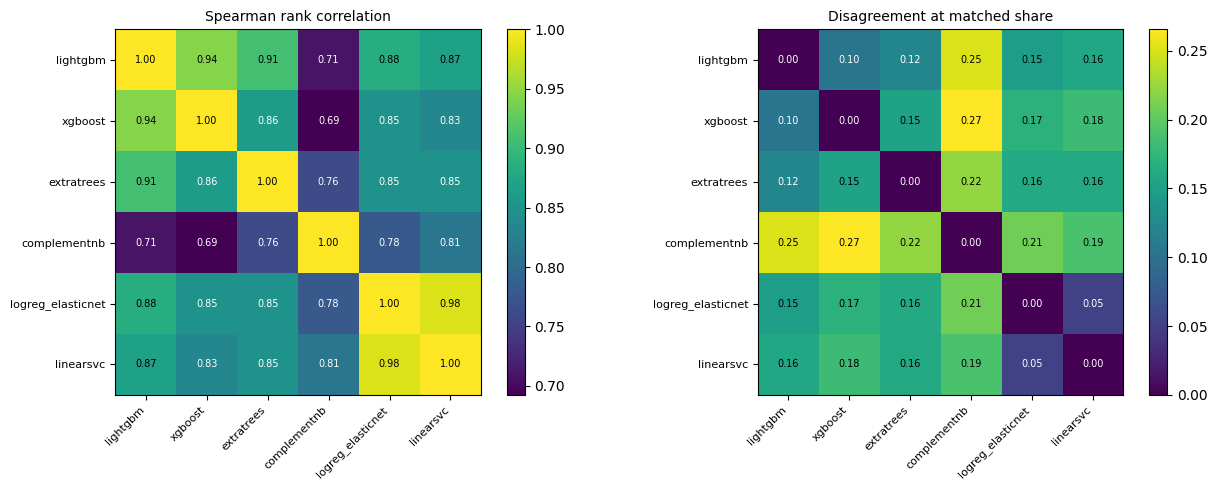

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, title in [(axes[0], corr, "Spearman rank correlation"),
                     (axes[1], disagree, "Disagreement at matched share")]:
    im = ax.imshow(m.to_numpy(), cmap="viridis")
    ax.set_xticks(range(len(m)), m.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(m)), m.index, fontsize=8)
    ax.set_title(title, fontsize=10)
    for i in range(len(m)):
        for j in range(len(m)):
            ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if m.iloc[i, j] < m.to_numpy().mean() else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIGURES / "ensemble_member_diversity.png", dpi=120)
plt.show()

## 6. The evaluation harness, and your lane

**Phase B is split by method.** Everyone now works on the same merged matrix, and each of
us sweeps a different family of combiner:

| member | lane key | what varies | section |
|---|---|---|---|
| Cliffton | `weights` | the weight vector: exhaustive simplex sweep, NNLS, hill-climb | 7 |
| Brian | `vote` | the decision rule: hard majority, weighted, k-of-n, soft vote | 8 |
| Jovyan | `meta` | the learned combiner: logistic, tree, boosted stumps, forward selection | 9 |
| Koko | `aggregate` | the aggregation operator: mean, median, trimmed, power, top-k Borda | 10 |

The lanes are orthogonal by construction, so nobody recomputes anyone else's work and the
merged leaderboard covers four independent axes at once.

**Every combiner is scored out of fold.** Notebook 10 originally fitted its weights on the
same 16,000 rows it reported them on and called the resulting bias small. With four people
sweeping dozens of configurations and a leaderboard that takes the maximum over all of
them, it is not small: whichever lane has the most free parameters wins on optimism alone.
`combiners.cv_evaluate` refits each combiner inside the locked folds and reports the
held-out AUC, so a 3,003-point sweep and a parameter-free median are compared on equal
terms. Each result also carries `auc_insample` and `auc_gap`, which measure the bias
instead of assuming it away.

**Two matrices are available.** `rank` is the rank matrix every combiner should normally
use. `raw` is the untransformed member scores, and exists only so one voting config can
reproduce what notebook 07 actually did - averaging raw probabilities and margins together.
Expect it to score badly: LinearSVC margins are on a completely different scale to the
others, so a raw mean is dominated by whichever member happens to have the widest spread.

Results go to `data/processed/ensemble_trials/` as one small JSON per configuration,
tracked in git and merged by glob - the same protocol as the tuning trials, so four people
sweep in parallel without ever editing the same file. A configuration whose file already
exists is skipped, so an interrupted sweep resumes where it stopped.

In [21]:
LANE_ASSIGNMENTS = {"cliffton": "weights", "brian": "vote",
                    "jovyan": "meta", "koko": "aggregate"}
LANE_SECTIONS = {"weights": 7, "vote": 8, "meta": 9, "aggregate": 10}
MY_LANE = LANE_ASSIGNMENTS[ME]

# Set True only to cover for an absent teammate; normally each of us runs one lane.
RUN_ALL_LANES = False

R, members = ensemble.rank_matrix(oof, ALL_MEMBERS)
S = np.column_stack([oof[m] for m in members])
MATRICES = {"rank": R, "raw": S}

print(f"{ME} owns lane '{MY_LANE}' - run section {LANE_SECTIONS[MY_LANE]}")
print(f"members (column order): {members}")
print(f"R {R.shape}, ranks in ({R.min():.5f}, {R.max():.2f}]")


def mine(lane):
    """True if this lane is yours to run."""
    return RUN_ALL_LANES or MY_LANE == lane

cliffton owns lane 'weights' - run section 7
members (column order): ['lightgbm', 'xgboost', 'extratrees', 'complementnb', 'logreg_elasticnet', 'linearsvc']
R (16000, 6), ranks in (0.00006, 1.00]


In [22]:
# Two calibration checks on the harness, run once by whoever gets here first. Both are
# about trusting the numbers in sections 7-10, so they are worth the 30 seconds.

# 1. How large is the optimism the harness removes? A single member is parameter-free and
#    should show ~0 gap; the exhaustive weight sweep takes a maximum over 3,003 vectors on
#    the same rows and should show a visibly positive one.
solo = combiners.cv_evaluate(lambda M, yy: (lambda Q: Q[:, 0]), R, y_dev, cv,
                             share=SHARE_DEV)
print(f"single member  held-out {solo['auc_mean']:.4f}  in-sample {solo['auc_insample']:.4f}"
      f"  gap {solo['auc_gap']:+.5f}")

# 2. The tie trap. A raw majority vote takes only len(members)+1 distinct values, so the
#    share cut lands inside a block of tied rows and every row in that block is labelled by
#    its position in the file rather than by any model. This measures how many rows that is.
raw_votes = combiners._labels_at_share(R, SHARE_DEV).sum(axis=1).astype(float)
fixed = combiners.fit_full("vote", {"kind": "hard_vote"}, R, y_dev)(R)
print(f"\nraw vote: {len(np.unique(raw_votes)):d} distinct values, "
      f"{combiners.tied_fraction_at_share(raw_votes, SHARE_DEV):.1%} of rows decided by "
      f"file order")
print(f"tie-broken: {len(np.unique(fixed)):d} distinct values, "
      f"{combiners.tied_fraction_at_share(fixed, SHARE_DEV):.1%} of rows decided by "
      f"file order")
print("\nThis is why every discrete combiner in lane B carries a rank tiebreak.")

single member  held-out 0.8453  in-sample 0.8453  gap -0.00005

raw vote: 7 distinct values, 7.1% of rows decided by file order
tie-broken: 15729 distinct values, 0.0% of rows decided by file order

This is why every discrete combiner in lane B carries a rank tiebreak.


## 7. Lane A - weighted rank blending (Cliffton)

All three variants produce a weight vector and then take a linear combination of member
ranks. What differs is how the vector is found, and each method fails differently:

- **`sweep`** is exhaustive over the simplex at a fixed step, so it cannot miss an optimum
  inside the grid - but its cost is combinatorial in the member count, which forces the grid
  coarse (3,003 points for 6 members at step 0.1, ~53,000 at 0.05). It is also the config
  most exposed to selection bias, since it reports a maximum over thousands of vectors;
  watch its `auc_gap`.
- **`nnls`** solves for the weights in closed form. Fast and bias-light, but it minimizes
  squared error rather than AUC, which is not the thing being optimized. Non-negativity is
  essential here: the members correlate 0.9+, and an unconstrained fit assigns large
  opposing weights that fit noise and do not transport.
- **`hill_climb`** optimizes AUC directly at a fine step, but only finds a local optimum.

`equal` is the control: it is what notebook 07's combiner amounts to once members are on a
common scale, so the gap between it and the rest is the value added by weighting at all.

In [23]:
CONFIGS_WEIGHTS = [
    {"kind": "equal"},
    {"kind": "sweep", "step": 0.2},
    {"kind": "sweep", "step": 0.1},
    {"kind": "nnls"},
    {"kind": "hill_climb", "step": 0.1},
    {"kind": "hill_climb", "step": 0.05},
    {"kind": "hill_climb", "step": 0.02},
]

if mine("weights"):
    res = combiners.run_lane("weights", ME, CONFIGS_WEIGHTS, MATRICES, y_dev, cv,
                             share=SHARE_DEV)
    print()
    print(res[["owner", "kind", "auc_mean", "auc_std", "auc_gap", "f1_mean"]]
          .round(5).to_string(index=False))
    print("\nWeights the best config learned on all rows:")
    print(dict(zip(members, np.round(res.iloc[0]["info"].get("weights", []), 3))))
else:
    print(f"lane 'weights' belongs to Cliffton - skipping (you are {ME}, lane {MY_LANE})")

[1/7] auc 0.8453 +/-0.0024  gap -0.0000  (0s)  equal 
[2/7] auc 0.8520 +/-0.0027  gap +0.0000  (7s)  sweep {'step': 0.2}
[3/7] auc 0.8521 +/-0.0028  gap +0.0001  (73s)  sweep {'step': 0.1}
[4/7] auc 0.8522 +/-0.0028  gap +0.0001  (0s)  nnls 
[5/7] auc 0.8523 +/-0.0028  gap +0.0002  (2s)  hill_climb {'step': 0.1}
[6/7] auc 0.8521 +/-0.0027  gap +0.0004  (2s)  hill_climb {'step': 0.05}
[7/7] auc 0.8524 +/-0.0029  gap +0.0001  (3s)  hill_climb {'step': 0.02}

   owner       kind  auc_mean  auc_std  auc_gap  f1_mean
cliffton hill_climb   0.85239  0.00285  0.00012  0.75287
cliffton hill_climb   0.85233  0.00277  0.00018  0.75353
cliffton       nnls   0.85216  0.00282  0.00013  0.75340
cliffton hill_climb   0.85215  0.00272  0.00040  0.75367
cliffton      sweep   0.85211  0.00276  0.00011  0.75473
cliffton      sweep   0.85199  0.00268  0.00002  0.75220
cliffton      equal   0.84533  0.00237 -0.00003  0.74633

Weights the best config learned on all rows:
{'lightgbm': np.float64(0.287), 'xgbo

## 8. Lane B - voting mechanisms (Brian)

Voting throws away magnitude and keeps only each member's verdict, which is the point: a
member that is badly calibrated but usually right still gets one full vote. The variants:

- **`hard_vote`** counts how many members call a row machine, after thresholding each member
  to the same share.
- **`weighted_vote`** weights each vote by that member's own AUC above chance, learned on
  the training rows only. ComplementNB should end up with very little say.
- **`k_of_n`** requires at least `k` members to agree. `k=1` is a union (recall-oriented),
  `k=6` is unanimity (precision-oriented), and the interesting behaviour is in between.
- **`soft_vote`** does not threshold at all, it just averages the columns. On the `rank`
  matrix that is the equal-weight blend. On the `raw` matrix it is **exactly what notebook
  07 did**, and it is included so the leaderboard shows what 07's combiner scores rather
  than us asserting it was wrong.

**The trap in this lane, already demonstrated in section 6.** A vote over 6 members takes 7
distinct values, so the share cut falls inside a tied block and roughly a fifth of the rows
get labelled by their position in the file rather than by any model. Every discrete
combiner here therefore adds a rank-based tiebreak that is provably too small to reorder
distinct vote levels. If you add your own vote rule, build it with
`combiners._break_ties(votes, Q)` rather than returning the raw counts.

Sweeping `share` is a real knob and not a duplicate of the submission-time share: it moves
where each *member's* own machine/human line falls before voting, which changes how
conservative the vote is. It is not the predicted balance of the final submission, which
section 13 sets separately.

In [24]:
CONFIGS_VOTE = [
    {"kind": "hard_vote"},
    {"kind": "weighted_vote"},
    {"kind": "k_of_n", "k": 2},
    {"kind": "k_of_n", "k": 3},
    {"kind": "k_of_n", "k": 4},
    {"kind": "k_of_n", "k": 5},
    {"kind": "soft_vote"},
    {"kind": "soft_vote", "matrix": "raw"},        # notebook 07's actual combiner
    {"kind": "hard_vote", "share": 0.45},
    {"kind": "hard_vote", "share": 0.50},
    {"kind": "hard_vote", "share": 0.55},
    {"kind": "weighted_vote", "share": 0.50},
]

if mine("vote"):
    res = combiners.run_lane("vote", ME, CONFIGS_VOTE, MATRICES, y_dev, cv,
                             share=SHARE_DEV)
    print()
    print(res[["owner", "kind", "config", "auc_mean", "auc_std", "auc_gap"]]
          .round(5).to_string(index=False))
else:
    print(f"lane 'vote' belongs to Brian - skipping (you are {ME}, lane {MY_LANE})")

lane 'vote' belongs to Brian - skipping (you are cliffton, lane weights)


## 9. Lane C - meta-learner stacking (Jovyan)

Lanes A, B and D all impose a *shape* on the combination: a weighted sum, a vote count, an
order statistic. This lane imposes none and lets a classifier learn the mapping from six
member ranks to a label, so it is the only lane that can find genuinely non-linear
structure, such as "trust LightGBM except when the linear models both strongly disagree".

**The risk this lane carries, and what to watch.** A tree with enough depth will memorize
16,000 rows of a 6-column matrix. Its `auc_insample` will look superb and its `auc_mean`
will not move, which is exactly what `auc_gap` is there to expose - the harness verification
confirmed a depth-20 tree at in-sample AUC 1.0000 against a held-out 0.8561. Keep depths
shallow, keep `min_samples_leaf` large, and report the gap alongside the score. If your best
config has a gap several times larger than lane D's, that is a warning and not a win.

`forward_select` is the odd one out: it answers "which members belong in the blend" rather
than "how should they be weighted", and it reports an explicit subset. Notebook 07 dropped
ComplementNB by hand; this lets the data make that call and say so in a form the report can
quote directly.

In [25]:
CONFIGS_META = [
    {"kind": "logistic", "C": 0.1},
    {"kind": "logistic", "C": 1.0},
    {"kind": "logistic", "C": 10.0},
    {"kind": "tree", "max_depth": 2},
    {"kind": "tree", "max_depth": 3},
    {"kind": "tree", "max_depth": 5},
    {"kind": "tree", "max_depth": 8, "min_samples_leaf": 20},
    {"kind": "gbm", "n_estimators": 50, "max_depth": 2},
    {"kind": "gbm", "n_estimators": 150, "max_depth": 2},
    {"kind": "gbm", "n_estimators": 150, "max_depth": 3, "learning_rate": 0.05},
    {"kind": "forward_select"},
    {"kind": "forward_select", "max_members": 3},
]

if mine("meta"):
    res = combiners.run_lane("meta", ME, CONFIGS_META, MATRICES, y_dev, cv,
                             share=SHARE_DEV)
    print()
    print(res[["owner", "kind", "config", "auc_mean", "auc_std", "auc_gap"]]
          .round(5).to_string(index=False))
    picked = [r for r in res["info"] if "members" in r]
    if picked:
        print(f"\nforward selection kept: {[members[i] for i in picked[0]['members']]}")
else:
    print(f"lane 'meta' belongs to Jovyan - skipping (you are {ME}, lane {MY_LANE})")

lane 'meta' belongs to Jovyan - skipping (you are cliffton, lane weights)


## 10. Lane D - rank aggregation operators (Koko)

Every operator here is unweighted, which is the point: lane A already asks which weights are
best, so this lane isolates the effect of the aggregation *function*. The useful ones are
the non-linear operators, because no weighted sum can imitate them:

- **`median` / `trimmed`** ignore outlying members, so one badly-ranked row from a weak
  member cannot drag down a row the others agree on. With ComplementNB in the pool this is
  the most likely operator to beat the mean.
- **`power`** with `p < 1` behaves like a soft minimum, so a row must satisfy *every* member
  to score highly; with `p > 1` like a soft maximum, where one enthusiastic member suffices.
  `p = 1` is the plain mean, and `geometric` is the `p -> 0` limit.
- **`min` / `max`** are those limits taken literally, and mostly show how far the family
  reaches before it stops working.
- **`borda_topk`** gives points only above a rank cutoff, so members vote on the rows they
  are confident about and abstain elsewhere.
- **`caruana`** is greedy selection *with replacement*: it repeatedly adds whichever member
  most improves the running mean, so a member picked 8 times out of 25 has an effective
  weight of 0.32 arrived at greedily rather than by grid search. It is the one config in
  this lane that learns anything, so it is the one whose `auc_gap` is worth watching.

**Plain Borda count is deliberately absent.** On normalized ranks it is the mean multiplied
by the member count, so it would appear on the leaderboard as a distinct operator while
being provably identical to `mean` - verified to produce byte-identical labels. `borda_topk`
is the version that is genuinely different.

In [26]:
CONFIGS_AGGREGATE = [
    {"kind": "mean"},
    {"kind": "median"},
    {"kind": "trimmed", "trim": 0.2},
    {"kind": "trimmed", "trim": 0.34},
    {"kind": "geometric"},
    {"kind": "power", "p": 0.25},
    {"kind": "power", "p": 0.5},
    {"kind": "power", "p": 2.0},
    {"kind": "power", "p": 4.0},
    {"kind": "power", "p": -2.0},
    {"kind": "min"},
    {"kind": "max"},
    {"kind": "borda_topk", "cut": 0.3},
    {"kind": "borda_topk", "cut": 0.5},
    {"kind": "borda_topk", "cut": 0.7},
    {"kind": "caruana", "n_iters": 25},
    {"kind": "caruana", "n_iters": 100},
]

if mine("aggregate"):
    res = combiners.run_lane("aggregate", ME, CONFIGS_AGGREGATE, MATRICES, y_dev, cv,
                             share=SHARE_DEV)
    print()
    print(res[["owner", "kind", "config", "auc_mean", "auc_std", "auc_gap"]]
          .round(5).to_string(index=False))
    car = [r for r in res["info"] if "weights" in r]
    if car:
        print(f"\ncaruana effective weights: "
              f"{dict(zip(members, np.round(car[0]['weights'], 3)))}")
else:
    print(f"lane 'aggregate' belongs to Koko - skipping (you are {ME}, lane {MY_LANE})")

lane 'aggregate' belongs to Koko - skipping (you are cliffton, lane weights)


### Push your lane's results

```bash
git add data/processed/ensemble_trials/
git commit -m "feat: <your lane> combiner results"
git push
```

This is sync point 2. `git pull` before section 11 so the leaderboard sees all four lanes.
Cliffton runs the rest.

## 11. The merged combiner leaderboard

Every configuration any of us ran, on one held-out scale, with the single members included
as the baseline they have to beat. `auc_gap` is the honesty column: a large gap means that
config's in-sample score was mostly optimism, and two configs with equal held-out AUC are
not equally trustworthy if one of them got there from a much higher in-sample number.

In [ ]:
lanes = combiners.load_results()
assert len(lanes), "no combiner results on disk - has anyone run a lane?"
print(f"{len(lanes)} configs across lanes {sorted(lanes['lane'].unique())} "
      f"from {sorted(lanes['owner'].unique())}")

# Single members, evaluated through the identical harness so they sit on the same scale.
baseline = pd.DataFrame([
    {"lane": "single", "owner": "-", "kind": m,
     **{k: v for k, v in combiners.cv_evaluate(
         (lambda j: (lambda M, yy: (lambda Q: Q[:, j])))(j),
         R, y_dev, cv, share=SHARE_DEV).items()
        if k in ("auc_mean", "auc_std", "f1_mean", "auc_insample", "auc_gap")}}
    for j, m in enumerate(members)])

board = (pd.concat([lanes.drop(columns=["config", "info", "seconds"]), baseline],
                   ignore_index=True)
         .sort_values("auc_mean", ascending=False).reset_index(drop=True))
print()
print(board.round(5).head(25).to_string(index=False))

best_member_row = board[board["lane"] == "single"].iloc[0]
best_member = best_member_row["kind"]
best_member_auc = float(best_member_row["auc_mean"])
print(f"\nbest single member: {best_member} (held-out AUC {best_member_auc:.4f})")

In [ ]:
# The report figure: held-out AUC against in-sample AUC, coloured by lane. Points far
# above the diagonal earned their in-sample score; points far to the left of it did not.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"weights": "tab:blue", "vote": "tab:orange", "meta": "tab:red",
          "aggregate": "tab:green", "single": "tab:gray"}
for lane_name, grp in board.groupby("lane"):
    axes[0].scatter(grp["auc_insample"], grp["auc_mean"], s=45, alpha=0.8,
                    label=lane_name, color=colors.get(lane_name))
lims = [board[["auc_insample", "auc_mean"]].to_numpy().min() - 0.002,
        board[["auc_insample", "auc_mean"]].to_numpy().max() + 0.002]
axes[0].plot(lims, lims, "k--", lw=0.8, label="no optimism")
axes[0].set_xlabel("in-sample AUC (what notebook 10 used to report)")
axes[0].set_ylabel("held-out AUC (what we select on)")
axes[0].set_title("Optimism by lane", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

top = board.head(15).iloc[::-1]
axes[1].barh(range(len(top)), top["auc_mean"] - best_member_auc,
             xerr=top["auc_std"], color=[colors.get(l, "gray") for l in top["lane"]])
axes[1].set_yticks(range(len(top)),
                   [f"{r.lane}/{r.kind}"[:34] for r in top.itertuples()], fontsize=7)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel(f"held-out AUC minus best single member ({best_member})")
axes[1].set_title("Top 15 combiners vs the model to beat", fontsize=10)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES / "ensemble_combiner_leaderboard.png", dpi=120)
plt.show()

## 12. Holdout arbitration, and the ship / no-ship guard

**The bar, stated before the results are known so it cannot be moved afterwards.** The
winning combiner ships only if it beats the best single member on held-out AUC by more than
the fold-to-fold standard deviation of that member. That is the same spirit as notebook 07's
guard, applied to an unbiased number instead of an in-sample one.

Two independent confirmations follow, because the leaderboard has now taken a maximum over
every configuration all four of us ran, and a maximum over enough noise is not zero:

1. **The holdout.** Members are fit on `dev_idx` only and the combiner is refitted on the
   dev OOF matrix, then both are evaluated once on the 4,000 rows nothing has touched.
   Primary metric is AUC, which is share-free.
2. **The runner-up from a different lane.** If the top two configs come from structurally
   different lanes and agree, that is far stronger evidence than one config winning by a
   hair. If the leaderboard is topped by six variants of the same thing, treat the margin as
   the search-noise it probably is.

In [ ]:
best_row = board[board["lane"] != "single"].iloc[0]
best_lane, best_kind = best_row["lane"], best_row["kind"]
best_config = lanes[(lanes["lane"] == best_lane) & (lanes["kind"] == best_kind)].iloc[0]["config"]

bar = float(best_member_row["auc_std"])
gain = float(best_row["auc_mean"]) - best_member_auc
ships = gain > bar

print(f"winner:            {best_lane}/{best_kind}  {best_config}")
print(f"held-out AUC       {best_row['auc_mean']:.4f} (in-sample {best_row['auc_insample']:.4f}, "
      f"gap {best_row['auc_gap']:+.4f})")
print(f"best single member {best_member_auc:.4f} ({best_member})")
print(f"gain               {gain:+.4f}")
print(f"the bar            {bar:.4f}  (fold-to-fold std of {best_member})")
print(f"clears the bar     {ships}")

# The runner-up from a structurally different lane.
others = board[(board["lane"] != "single") & (board["lane"] != best_lane)]
runner = others.iloc[0] if len(others) else None
if runner is not None:
    runner_config = lanes[(lanes["lane"] == runner["lane"]) &
                          (lanes["kind"] == runner["kind"])].iloc[0]["config"]
    print(f"\nrunner-up (different lane): {runner['lane']}/{runner['kind']} "
          f"{runner['auc_mean']:.4f} ({runner['auc_mean'] - best_member_auc:+.4f})")

In [ ]:
# Holdout: members fit on dev only, combiner refit on the dev OOF matrix, one evaluation.
hold_scores = {}
for name in ALL_MEMBERS:
    if name == "lightgbm":
        fits = [build(name, seed=s).fit(X_dev, y_dev) for s in SEEDS]
        hold_scores[name] = ensemble.seed_average(
            [ensemble.member_score(f, X_hold) for f in fits])
    else:
        hold_scores[name] = ensemble.member_score(build(name).fit(X_dev, y_dev), X_hold)
    print(f"{name:20s} holdout AUC {roc_auc_score(y_hold, hold_scores[name]):.4f}")

R_hold, _ = ensemble.rank_matrix(hold_scores, members)
share_hold = float(y_hold.mean())

winner_fn = combiners.fit_full(best_lane, best_config, R, y_dev)
blend_hold = winner_fn(R_hold)

print(f"\nwinner  holdout AUC  {roc_auc_score(y_hold, blend_hold):.4f}")
print(f"{best_member:7s} holdout AUC  {roc_auc_score(y_hold, hold_scores[best_member]):.4f}")
print(f"winner  holdout F1 @ {share_hold:.4f} share  "
      f"{ensemble.macro_f1_at_share(blend_hold, y_hold, share_hold):.4f}")
print(f"{best_member:7s} holdout F1 @ {share_hold:.4f} share  "
      f"{ensemble.macro_f1_at_share(hold_scores[best_member], y_hold, share_hold):.4f}")
print("\nThe holdout is a single 4,000-row sample, so read it as a consistency check on "
      "the sign of the gain rather than as a second precise estimate.")

## 13. Full refit and the submission batch

Benchmark: `lightgbm_share50.csv` at share 0.4996 scored **0.73583**, and it is already on
the board. Because this notebook uses the same tuned LightGBM, that benchmark *is* the
matched-share control - the ensemble is compared against it directly, with no confound and
without spending an upload to re-establish it.

One caveat to record rather than hide: the benchmark was a single-seed fit, while the
`lightgbm` member here is rank-averaged over 5 seeds. That is a small difference in the same
direction for every file below, so it does not affect the comparison between them, but it
means the ensemble's margin over 0.73583 includes whatever seed-averaging is worth.

**Only two slots are justified.** The winning combiner, and the runner-up from a
structurally different lane as a hedge. Everything below +/-0.0084 is a tie, so a third
variant of the same idea buys nothing.

In [ ]:
BENCH_SHARE = 0.4996  # lightgbm_share50.csv, Kaggle 0.73583

sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
assert len(test_ids) == 6999, len(test_ids)
assert list(test_ids) == list(sample["id"]), "test ids do not match sample_submission order"

test_scores = {}
fitted = {}
for name in ALL_MEMBERS:
    print(f"full refit: {name} ...", flush=True)
    if name == "lightgbm":
        fits = [build(name, seed=s).fit(X, y) for s in SEEDS]
        fitted[name] = fits
        test_scores[name] = ensemble.seed_average(
            [ensemble.member_score(f, Xt) for f in fits])
    else:
        est = build(name).fit(X, y)
        fitted[name] = est
        test_scores[name] = ensemble.member_score(est, Xt)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(fitted, paths.MODELS / "round4_members_full_refit.pkl")
R_test, _ = ensemble.rank_matrix(test_scores, members)
print("\nrefit complete")

In [ ]:
def write_at_share(scores, target_share, filename):
    """Label the top `target_share` of test rows machine and write the submission."""
    preds = ensemble.threshold_at_share(scores, target_share)
    data.write_submission(test_ids, preds, filename)
    return {"file": filename, "actual_share": round(float(preds.mean()), 4),
            "tied_frac": round(combiners.tied_fraction_at_share(scores, target_share), 4)}


batch = []
if ships:
    winner_test = combiners.fit_full(best_lane, best_config, R, y_dev)(R_test)
    batch.append(write_at_share(winner_test, BENCH_SHARE,
                                f"ensemble_{best_lane}_{best_kind}_share50.csv"))
    if runner is not None:
        runner_test = combiners.fit_full(runner["lane"], runner_config, R, y_dev)(R_test)
        batch.append(write_at_share(runner_test, BENCH_SHARE,
                                    f"ensemble_{runner['lane']}_{runner['kind']}_share50.csv"))
else:
    print("The ensemble did NOT clear the bar - no submission written.\n"
          "That is the finding, and it is the same answer notebook 07 reached but this "
          "time on diverse members, an unbiased metric and four families of combiner.\n"
          "Write it up in the discussion section rather than lowering the bar.\n")

if batch:
    batch = pd.DataFrame(batch)
    bench = pd.read_csv(paths.SUBMISSIONS / "lightgbm_share50.csv")["label"].to_numpy()
    batch["rows_vs_benchmark"] = [
        int((pd.read_csv(paths.SUBMISSIONS / f)["label"].to_numpy() != bench).sum())
        for f in batch["file"]]
    print(batch.to_string(index=False))
    print("\nUnder ~200 differing rows the comparison is under-powered against the 0.0084 "
          "noise floor - a null result there must not be read as 'no difference' "
          "(09 section 9's share53 lesson).")
    print("tied_frac above ~0.01 means the combiner is too coarse and the share cut is "
          "splitting a tied block by file order.")

In [ ]:
# Format and correctness guards, matching 07/08/09. Run before uploading anything.
for f in batch["file"] if len(batch) else []:
    sub = pd.read_csv(paths.SUBMISSIONS / f, dtype={"id": str})
    assert list(sub.columns) == ["id", "label"], sub.columns
    assert list(sub["id"]) == list(sample["id"]), f"{f}: id order does not match sample"
    assert set(sub["label"].unique()) <= {0, 1}, f"{f}: labels outside 0/1"
    assert abs(sub["label"].mean() - BENCH_SHARE) < 1 / len(sub), f"{f}: share drifted"
    print(f"{f:44s} OK  n={len(sub)}  share={sub['label'].mean():.4f}")

# Identity check: a combiner that puts all weight on one member must reproduce that
# member's own ranking exactly. If this fails, the rank/blend plumbing is wrong.
solo_w = np.zeros(len(members)); solo_w[members.index("lightgbm")] = 1.0
assert np.array_equal(
    ensemble.threshold_at_share(ensemble.blend(R_test, solo_w), BENCH_SHARE),
    ensemble.threshold_at_share(test_scores["lightgbm"], BENCH_SHARE)), "identity check failed"
print("\nidentity check passed: weight-1.0 blend == that member alone")

In [ ]:
ledger_path = paths.DATA_PROCESSED / "round4_results.csv"
if len(batch):
    ledger = batch[["file", "actual_share", "rows_vs_benchmark"]].copy()
    ledger["kaggle_f1"] = np.nan
    if ledger_path.exists():
        prev = pd.read_csv(ledger_path)[["file", "kaggle_f1"]].dropna()
        if len(prev):
            ledger = ledger.drop(columns="kaggle_f1").merge(prev, on="file", how="left")
    ledger.to_csv(ledger_path, index=False)
    print(ledger.to_string(index=False))

print(f"\nBenchmark to beat: lightgbm_share50.csv, share 0.4996, Kaggle 0.73583")
print(f"Anything within +/-0.0084 of it is a tie, not a result.")

## Discussion / carry-forward -> Task 4 report

_Fill in once the batch is scored._

**What to record regardless of outcome.** Notebook 07 concluded the ensemble was not worth
having. This notebook re-ran that question with members chosen for measured diversity
(13.7% disagreement rather than 11.4% among near-identical linear models), with two
instruments corrected (rank blending instead of probability averaging, out-of-fold AUC
instead of F1 at a fixed cutoff), and across four families of combiner rather than one. The
`vote/soft_vote` config on the `raw` matrix is literally 07's combiner, so the leaderboard
shows what 07 would have scored on this member set instead of us asserting it was wrong.

**Three things worth writing up even if the ensemble ships nothing:**

1. **The optimism measurement.** The left panel of `ensemble_combiner_leaderboard.png` shows
   in-sample against held-out AUC per lane. Report the lane with the largest `auc_gap` and
   what it would have looked like under notebook 10's original in-sample selection - this is
   a concrete instance of the general methodological point the project has been making since
   notebook 09, that a comparison is only as good as the axis it holds fixed.
2. **The tie trap.** A majority vote over 6 members takes 7 distinct values, so a
   share-thresholded submission built from it has roughly a fifth of its labels decided by
   row order rather than by any model. Section 6 measures this on real data. It also forced a
   fix to `threshold_at_share`, which previously used a quantile cut and missed the target
   share by up to 19 rows on 6,999 tied scores.
3. **Whether diversity or member quality won.** 07 concluded "diversity is necessary but not
   sufficient" from a single rejected member. With ComplementNB, ExtraTrees and two boosting
   models in the pool and four combiner families given the chance to use them, this is now
   answerable properly: check whether `forward_select` and the sweep agree about which
   members to drop.

**Read the batch against the benchmark:** `lightgbm_share50.csv` at 0.73583 is the
matched-share control, so each uploaded file's score minus 0.73583 is the ensemble's gain,
with nothing else varying. Anything inside +/-0.0084 is a tie. Say so plainly if that is
what happened - 09 section 9 is the precedent, where a 0.0032 move was correctly called
noise rather than being written up as a regression.

**Still open, and a deliberate decision rather than an oversight:** the two final private-LB
picks. Both current picks are LightGBM near the same share, which is no hedge at all. Per 09
section 9, the right choice depends on what fraction of test rows the public leaderboard
scores - ~51% means a random split and both picks belong near the peak; 28.6% or 71.4% means
the split follows the UUID-vs-numeric `id` boundary, and pick 2 should hedge on *share* with
a train-matched 0.6252 variant instead.

**Not pursued here, and why:** share tuning stays closed (09 section 9 established the
0.45-0.55 band is flat to within noise), and no new base models were added - the point of
this round is to test whether the members we already have can be combined, not to widen the
pool again.